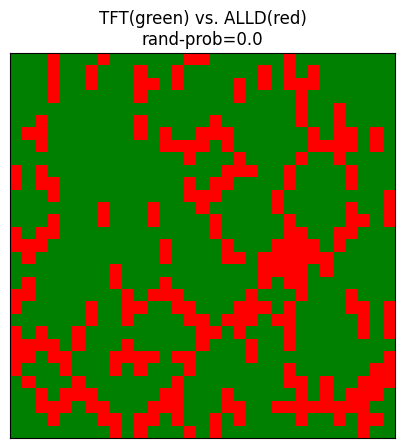

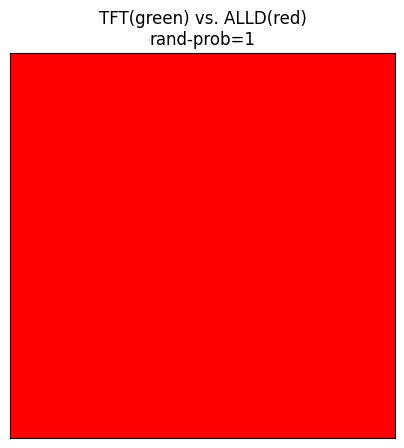

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==========================
# 1) パラメータ設定
# ==========================
N = 31                   # グリッドサイズ (N x N)
MAX_STEPS = 100          # アニメーションを表示するステップ数
p0 = 0.5                 # 初期に TFT(=1) を配置する確率 (残りはALLD=0)
b = 1.0                  # 協力の利得ベネフィット
c = 0.0                  # 協力コスト
k = 4                    # 1回のプレイで繰り返す回数 (iterated game)

# ALLD=0(赤), TFT=1(緑)
# matplotlibのカラーマップを指定しておく
from matplotlib.colors import ListedColormap
cmap_2strategy = ListedColormap(["red", "green"])


# ==========================
# 2) ヘルパー関数
# ==========================
def initialize_strategy_grid(n, prob_TFT=0.5):
    """
    N×N グリッドを用意し、prob_TFT の確率で TFT(=1)、それ以外を ALLD(=0) とする。
    """
    rand_grid = np.random.rand(n, n)
    strategy_grid = (rand_grid < prob_TFT).astype(int)
    return strategy_grid

def get_neighbors_4(n, x, y):
    """
    上下左右4近傍（トーラス）を返す
    """
    return [
        ((x - 1) % n, y),
        ((x + 1) % n, y),
        (x, (y - 1) % n),
        (x, (y + 1) % n),
    ]

def randomize_locations(strategy_grid, randomization_prob):
    """
    NetLogoの randomize-locations 相当:
      - 各セル(x,y)をランダム順に訪れ、確率 randomization_prob で
        ランダムに別セル(nx, ny)と戦略をスワップ。
    """
    n = strategy_grid.shape[0]
    coords = [(x,y) for x in range(n) for y in range(n)]
    random.shuffle(coords)
    
    for (x, y) in coords:
        if random.random() < randomization_prob:
            # 別の場所をランダムに選ぶ
            nx, ny = random.choice(coords)
            # 同じセルならやり直しするなら while で避けてもよい (が簡略化のため省略)
            
            # スワップ
            tmp = strategy_grid[x,y]
            strategy_grid[x,y] = strategy_grid[nx,ny]
            strategy_grid[nx,ny] = tmp

def play_game(strategy_grid, b, c, k):
    """
    各セルの利得を計算して payoff_grid を返す (2戦略版).
      - ALLD(=0): payoff = k * (neighbors_TFT * b)
      - TFT ( =1): payoff = k * (neighbors_TFT * (b-c)) - (neighbors_ALLD * c)
    ここで neighbors_TFT は近傍にいる TFT の数,
            neighbors_ALLD は近傍にいる ALLD の数.
    """
    n = strategy_grid.shape[0]
    payoff_grid = np.zeros((n, n), dtype=float)
    
    for x in range(n):
        for y in range(n):
            my_str = strategy_grid[x, y]
            neighbors = get_neighbors_4(n, x, y)
            
            # 近傍内のALLD数/TFT数を数える
            neighbors_TFT = 0
            neighbors_ALLD = 0
            for (nx, ny) in neighbors:
                if strategy_grid[nx, ny] == 1:
                    neighbors_TFT += 1
                else:
                    neighbors_ALLD += 1
            
            if my_str == 0:
                # ALLD
                payoff_grid[x, y] = k * (neighbors_TFT * b)
            else:
                # TFT
                payoff_grid[x, y] = k * (neighbors_TFT*(b - c)) - (neighbors_ALLD*c)
    
    return payoff_grid

def evolve(strategy_grid, payoff_grid):
    """
    NetLogo の evolve 相当:
      - 各セルは近傍4マスを見て、最も利得が高い個体を探す
      - もしそれが自分より利得が高ければ模倣する (戦略をコピー)
    """
    n = strategy_grid.shape[0]
    new_grid = strategy_grid.copy()
    
    coords = [(x, y) for x in range(n) for y in range(n)]
    random.shuffle(coords)  # 更新順をランダムに
    
    for (x, y) in coords:
        my_payoff = payoff_grid[x, y]
        neighbors = get_neighbors_4(n, x, y)
        
        best_payoff = my_payoff
        best_str = strategy_grid[x, y]
        
        for (nx, ny) in neighbors:
            if payoff_grid[nx, ny] > best_payoff:
                best_payoff = payoff_grid[nx, ny]
                best_str = strategy_grid[nx, ny]
        
        if best_payoff > my_payoff:
            new_grid[x, y] = best_str
    
    return new_grid

def step_simulation(strategy_grid, randomization_prob):
    """
    1ステップ:
      1) randomize_locations
      2) play_game -> payoff_grid
      3) evolve
    """
    # 1) ランダム位置交換
    randomize_locations(strategy_grid, randomization_prob)
    
    # 2) 利得計算
    payoff_grid = play_game(strategy_grid, b=b, c=c, k=k)
    
    # 3) 戦略更新
    new_grid = evolve(strategy_grid, payoff_grid)
    
    return new_grid


# ==========================
# 3) アニメーション生成
# ==========================
def animate_TFTvsALLD(randomization_prob=0.09, steps=100):
    """
    randomization_prob の設定でシミュレーションし、
    t=0 から t=steps までの空間配置をアニメーション表示 (HTML) する。
    """
    # 初期化
    grid = initialize_strategy_grid(N, prob_TFT=p0)
    
    # 状態を保存
    grid_history = [grid.copy()]
    
    # シミュレーション実行
    for _ in range(steps):
        grid = step_simulation(grid, randomization_prob)
        grid_history.append(grid.copy())
    
    # アニメーション描画
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(grid_history[0], cmap=cmap_2strategy, vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"TFT(green) vs. ALLD(red)\nrand-prob={randomization_prob}")
    
    def update(frame):
        im.set_data(grid_history[frame])
        return [im]
    
    ani = FuncAnimation(fig, update, frames=len(grid_history), interval=200, blit=True)
    
    return HTML(ani.to_jshtml())


# ==========================
# 4) 実行例
# ==========================
if __name__ == "__main__":
    # 例1: randomization_prob=0.0 (左図に相当: 安定して緑が生き残るかも)
    HTML_obj1 = animate_TFTvsALLD(randomization_prob=0.0, steps=100)
    
    # 例2: randomization_prob=0.1 (右図に相当: ALLD が完全に支配的になる可能性大)
    HTML_obj2 = animate_TFTvsALLD(randomization_prob=1, steps=100)
    
    # Jupyter/Colab 上なら display(HTML_obj1), display(HTML_obj2) でアニメを確認可能
    #display(HTML_obj1)
    #display(HTML_obj2)


1
2
3
4
5
6
1
2
3
4
5
6


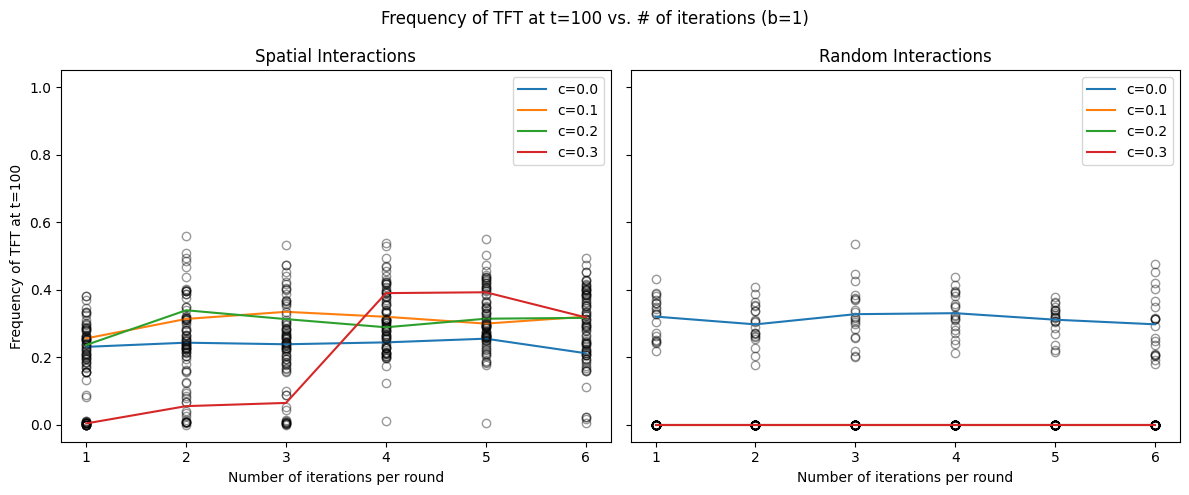

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ==========================================
# 1) パラメータ設定
# ==========================================
N = 31
T_MAX = 100            # シミュレーションステップ数
B = 1.0               # 利得の "利益"
C_VALUES = [0.0, 0.1, 0.2, 0.3]  # 複数のコスト
NUM_ITER_LIST = [1,2,3,4,5,6]    # 1ラウンド内の繰り返し回数(例)
NUM_RUNS = 20         # 各条件での繰り返し試行

# 初期戦略の内訳 (例: 20% TFT, 残り80%をALLDとALLC半々)
TFT_RATIO = 0.2
ALLD_RATIO = 0.4  # 80%の半分
ALLC_RATIO = 0.4  # 80%の半分

# 3種類の戦略を数字に対応させる:
#   0 => ALLD (赤)
#   1 => ALLC (青)
#   2 => TFT  (緑)
strategy_labels = {0: "ALLD", 1: "ALLC", 2: "TFT"}

# ==========================================
# 2) 初期化, 近傍取得, 利得計算, 進化
# ==========================================
def initialize_three_strategies(n, tft_ratio, alld_ratio, allc_ratio):
    """
    N*N のエージェントを用意し、
      tft_ratio (%) を TFT (=2),
      alld_ratio (%) を ALLD (=0),
      allc_ratio (%) を ALLC (=1)
    にランダム配置。
    """
    total = n*n
    n_tft  = int(round(total * tft_ratio))
    n_alld = int(round(total * alld_ratio))
    n_allc = total - n_tft - n_alld  # 端数は調整
    
    arr = [2]*n_tft + [0]*n_alld + [1]*n_allc
    random.shuffle(arr)
    strategy_grid = np.array(arr).reshape((n, n))
    return strategy_grid

def get_neighbors_spatial(n, x, y):
    """上下左右4近傍(トーラス)"""
    return [
        ((x-1) % n, y),
        ((x+1) % n, y),
        (x, (y-1) % n),
        (x, (y+1) % n),
    ]

def get_neighbors_random(n, x, y):
    """ランダム近傍: グリッド全体から1つ選ぶ (あるいは複数回選ぶ)"""
    # ここでは「1回の進化で誰を参照するか」という意味で
    # NetLogo の記述に合わせるなら、「最大利得の相手」を探す際に
    # 近傍候補として 4つ ランダムに取る、など色々と考え方があります。
    # 簡単のため「自分以外の全セル」を4つランダムに抽出するとみなす:
    # あるいは全員の中で利得最大を1体見る…などアレンジ可。
    
    coords = []
    # 4回分ランダム抽出（重複なし）
    #  -> NetLogoのneighbors4相当の「数だけ」ランダムピックする例
    possible = [(i,j) for i in range(n) for j in range(n) if not (i==x and j==y)]
    chosen = random.sample(possible, 4)
    coords.extend(chosen)
    return coords

def play_game(strategy_grid, b, c, num_iter):
    """
    各セルの利得を計算して payoff_grid に格納。
    NetLogoコードの記述に合わせ:
      - ALLC(=1):  payoff = num_iter * [ neighborsC*(b-c) - neighborsD*c ]
      - TFT ( =2): payoff = num_iter * [ neighborsC*(b-c) ] - neighborsD*c
      - ALLD(=0):  payoff = num_iter * [ neighborsC*b ]
    ただし neighborsC は近傍のうち (1=ALLC or 2=TFT) の個体数,
           neighborsD は近傍のうち (0=ALLD) の個体数
    """
    n = strategy_grid.shape[0]
    payoff_grid = np.zeros((n, n), dtype=float)
    
    for x in range(n):
        for y in range(n):
            my_str = strategy_grid[x,y]
            
            # 近傍の戦略
            # -> ここはあとで evolve() の実装で "spatial or random" を分岐するので、
            #    とりあえず payoff 計算用の近傍は「実際に誰とゲームするか」を決める部分。
            # NetLogoだと "neighbors4" となっているが、ここを空間・ランダムで切り替えてもOK。
            # 例: 空間ゲームにしたいなら neighbors = get_neighbors_spatial(n,x,y)
            #     ランダムゲームにしたいなら neighbors = get_neighbors_random(n,x,y)
            # …ただし、今回サンプルでは「空間ORランダムの切り替え」は evolve 側でやる想定にし、
            #    payoff は全セルに対して"空間近傍"で計算すると仮定する等、実装は一つの例。
            # 
            # ひとまず「空間で計算する」例としておく:
            neighbors = get_neighbors_spatial(n,x,y)
            
            neighborsC = 0
            neighborsD = 0
            for (nx, ny) in neighbors:
                if strategy_grid[nx, ny] == 0:
                    neighborsD += 1
                else:
                    # 1=ALLC or 2=TFT
                    neighborsC += 1
            
            if my_str == 1:  # ALLC
                payoff_grid[x,y] = num_iter * (neighborsC*(b-c) - neighborsD*c)
            elif my_str == 2:  # TFT
                payoff_grid[x,y] = num_iter * (neighborsC*(b-c)) - neighborsD*c
            else:  # ALLD=0
                payoff_grid[x,y] = num_iter * (neighborsC*b)
    
    return payoff_grid

def evolve(strategy_grid, payoff_grid, spatial=True):
    """
    NetLogoの evolve 相当:
      - 各セル(x,y) が「近傍のうち利得が最大の個体」を探し、
        もしそれが自分より利得が大きければその戦略を模倣。
      - ここで 近傍 は ( spatial ? => 上下左右4マス ) : ( random => ランダムに4マス抽出 ) 
    """
    n = strategy_grid.shape[0]
    new_grid = strategy_grid.copy()
    
    coords = [(x,y) for x in range(n) for y in range(n)]
    random.shuffle(coords)  # ランダム順更新
    
    for (x, y) in coords:
        my_payoff = payoff_grid[x,y]
        if spatial:
            neighbors = get_neighbors_spatial(n,x,y)
        else:
            neighbors = get_neighbors_random(n,x,y)
        
        best_payoff = my_payoff
        best_str = strategy_grid[x,y]
        for (nx, ny) in neighbors:
            if payoff_grid[nx, ny] > best_payoff:
                best_payoff = payoff_grid[nx, ny]
                best_str = strategy_grid[nx, ny]
        
        if best_payoff > my_payoff:
            new_grid[x,y] = best_str
    
    return new_grid

def run_simulation_once(num_iter, c, spatial=True):
    """
    1回分のシミュレーションを実行:
      - 初期化 (20%TFT,40%ALLD,40%ALLC)
      - 各ステップで
         1) play_game -> payoff_grid
         2) evolve(空間orランダム)
      - t=100終了時の TFT 割合を返す
    """
    grid = initialize_three_strategies(N, TFT_RATIO, ALLD_RATIO, ALLC_RATIO)
    
    for t in range(T_MAX):
        payoff_grid = play_game(grid, b=B, c=c, num_iter=num_iter)
        new_grid = evolve(grid, payoff_grid, spatial=spatial)
        grid = new_grid
    
    # 最終的な TFT(=2) の割合
    tft_fraction = np.mean(grid == 2)
    return tft_fraction


# ==========================================
# 3) 結果を集計 & グラフ描画
# ==========================================

def collect_data(spatial=True):
    """
    spatial=True なら空間近傍,
    spatial=False ならランダム近傍,
    について (num_iter, c) を変化させて T=100時点のTFT率を集計
    """
    results_dict = {}  # {(num_iter, c) : [20回の結果], ...}
    for num_iter in NUM_ITER_LIST:
        print(num_iter)
        for c in C_VALUES:
            run_values = []
            for _ in range(NUM_RUNS):
                val = run_simulation_once(num_iter, c, spatial=spatial)
                run_values.append(val)
            results_dict[(num_iter, c)] = run_values
    return results_dict

# ---- 実行 ----
if __name__ == "__main__":
    
    # 1) 空間近傍
    data_spatial = collect_data(spatial=True)
    # 2) ランダム近傍
    data_random  = collect_data(spatial=False)
    
    # グラフ描画を2つのサブプロットで (左: spatial, 右: random)
    fig, axes = plt.subplots(1,2, figsize=(12,5), sharey=True)
    ax_spatial, ax_random = axes
    
    # x軸 = NUM_ITER_LIST
    xvals = NUM_ITER_LIST
    
    # --- 左: spatial ---
    ax_spatial.set_title("Spatial Interactions")
    ax_spatial.set_xlabel("Number of iterations per round")
    ax_spatial.set_ylabel("Frequency of TFT at t=100")
    
    for c in C_VALUES:
        # c 固有のデータを取り出して平均を線でつなぐ
        means = []
        for ni in xvals:
            run_vals = data_spatial[(ni, c)]
            means.append(np.mean(run_vals))
            # 個々の試行 (open circles)
            ax_spatial.plot([ni]*NUM_RUNS,
                            run_vals,
                            marker='o',
                            fillstyle='none',
                            color='black',
                            alpha=0.4,
                            linestyle='None')
        ax_spatial.plot(xvals, means, label=f"c={c}")
    
    ax_spatial.set_ylim(-0.05, 1.05)
    ax_spatial.legend(loc='best')
    
    # --- 右: random ---
    ax_random.set_title("Random Interactions")
    ax_random.set_xlabel("Number of iterations per round")
    # ax_random.set_ylabel("Frequency of TFT at t=100")  # sharey=True なので省略
    
    for c in C_VALUES:
        means = []
        for ni in xvals:
            run_vals = data_random[(ni, c)]
            means.append(np.mean(run_vals))
            ax_random.plot([ni]*NUM_RUNS,
                           run_vals,
                           marker='o',
                           fillstyle='none',
                           color='black',
                           alpha=0.4,
                           linestyle='None')
        ax_random.plot(xvals, means, label=f"c={c}")
    
    ax_random.set_ylim(-0.05, 1.05)
    ax_random.legend(loc='best')
    
    plt.suptitle("Frequency of TFT at t=100 vs. # of iterations (b=1)")
    plt.tight_layout()
    plt.show()
